# Treasury market

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from dbnomics import fetch_series

In [3]:
# Paramétrage des styles utilisés par matplotlib
plt.style.use('default')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

In [5]:
# Utilities

# Inflation
df = pd.read_csv("Data/USCPI_1774-2024.csv", skiprows=2) 
df["Year"] = df["Year"].astype(int)
df.set_index("Year", inplace=True)
cpi = df["U.S. Consumer Price Index *"]
cpi.index.name = None

def real_price(value,date=None,base=2024):
    if type(value) == list:
        l = []
        for i in value:
            l.append(float(i*cpi[base]/cpi[date]))
        return l
    elif type(value) == type(np.array([])):
        return value*cpi[base]/cpi[date]
    elif type(value) == type(pd.Series([])):
        return value/(cpi/cpi.loc[base])
    else:
        return float(value*cpi[base]/cpi[date])
    
#GDP
df = pd.read_csv("Data/USGDP_1790-2024.csv", skiprows=1, thousands=',')
df = df.set_index('Year')
nominal_gdp = df['Nominal GDP (million of Dollars)']
real_gdp = df['Real GDP (millions of 2017 dollars)']

## According to Flow of Funds data

Code :
* Le .Q à la fin c'est pour donnée Quaterly (et.A pour annuelle).
* FL : pour les niveaux
* Secteur c'est les deux chiffres suivants
* 30611 c'est pour l'instrument (Treasuries)
* 05 pour les "computed series"

Code pour le moment :
* FL143061105.Q : Nonfinancial business (S11) 
* FL153061105.Q : Households and nonprofit organizations (S14+S15)
* FL263061105.Q : Rest of the World (S2)*
* FL383061105.Q : Domestic nonfinancial sectors
* FL403061105.Q : Government-sponsored enterprises (GSEs)
* FL473061105.Q : Credit Unions
* FL513061105.Q : Property-casualty insurance companies*
* FL523061105.Q : Insurance companies (S128)
* FL533061105.Q : Closed-end and exchange-traded funds
* FL543061105.Q : Life insurance companies*
* FL573061105.Q : Private pension funds
* FL583061105.Q : Insurance companies and pension funds (S128+S129) 
* FL593061105.Q : Pension funds (S129)
* FL603061105.Q : Other financial intermediaries except insurance companies, pension funds, financial auxiliaries and captive financial institutions and money lenders (S125)
* FL803061105.Q : Other financial intermediaries except insurance companies and pension funds (S125+S126+S127) 
* FL633061105.Q : Money market funds (S123)
* FL653061105.Q : Mutual funds*
* FL663061105.Q : Security brokers and dealers (S127 ?)
* FL693061105.Q : Non-MMF investment funds (S124)
* FL703061105.Q : Private depository institutions (S122)
* FL713061125.Q : Monetary authority (S121)
* FL783061105.Q : Private depository institutions and money market funds (S122+S123)
* FL793061105.Q : Domestic financial sectors (S12)
* FL893061105.Q : All sectors


\* petite incertitude pcq y'a trois séries possibles sur dbnmics, probablement une erreur

In [4]:
import dbnomics
import pandas as pd
import matplotlib.pyplot as plt

# Sélection des séries (sans double comptage)
codes = {
    "Nonfinancial business (S11)": "FL143061105.Q",
    "Rest of World (S2)": "FL263061105.Q",
    "Households and non-profit organizations (S14+S15)": "FL153061105.Q",
    "Monetary authority (S121)": "FL713061125.Q",
    "Private Depository Institutions (S122)": "FL703061105.Q",
    "Money Market Funds (S123)": "FL633061105.Q",
    "Mutual Funds (S124)": "FL653061105.Q",
    "Other financial intermediaries except insurance companies and pension funds (S125+S126+S127)" : "FL803061105.Q",
    "Insurance companies (S128)": "FL523061105.Q",
    "Pension Funds (S129)": "FL593061105.Q",
    "Security brokers and dealers": "FL663061105.Q",
    "Closed-end and exchange-traded funds": "FL533061105.Q"
}

# Télécharger et assembler les séries
dfs = []
for label, code in codes.items():
    data = dbnomics.fetch_series(f"FED/Z1/{code}")
    df_temp = data[['period', 'value']].dropna()
    df_temp['period'] = pd.PeriodIndex(df_temp['period'], freq='Q').to_timestamp()
    df_temp = df_temp.set_index('period').rename(columns={'value': label})
    dfs.append(df_temp)

df = pd.concat(dfs, axis=1)

# Télécharger la série "All sectors"
all_sectors = dbnomics.fetch_series("FED/Z1/FL893061105.Q")
all_sectors = all_sectors[['period', 'value']].dropna()
all_sectors['period'] = pd.PeriodIndex(all_sectors['period'], freq='Q').to_timestamp()
all_sectors = all_sectors.set_index('period')['value']

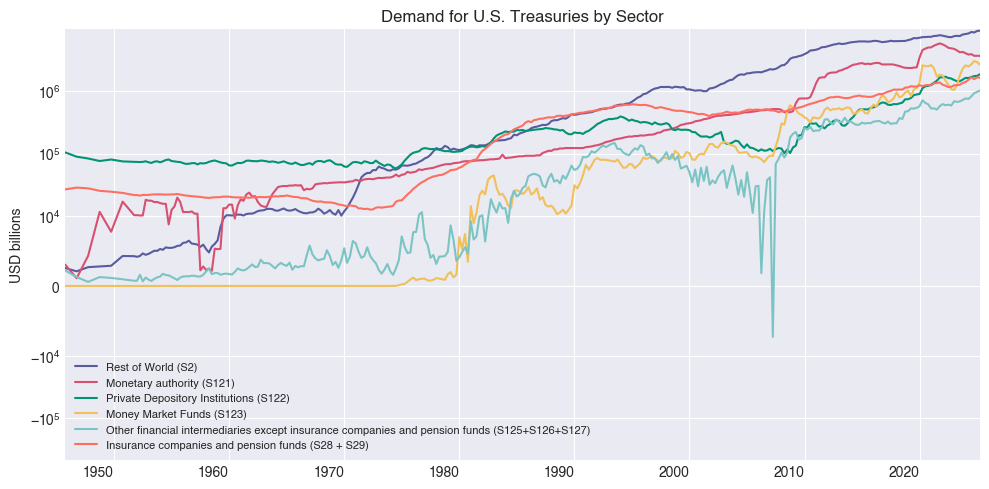

In [5]:
df1 = df.copy()
df1["Insurance companies and pension funds (S28 + S29)"] = df1["Insurance companies (S128)"] + df1["Pension Funds (S129)"]

df1 = df1.drop(columns=["Households and non-profit organizations (S14+S15)",
                        "Mutual Funds (S124)", "Nonfinancial business (S11)",
                        "Insurance companies (S128)",
                        "Pension Funds (S129)",
                        "Security brokers and dealers",
                        "Closed-end and exchange-traded funds"])
df1.index.name = None

#start_date = '1945-01-01'
#end_date = '1991-01-01'
#df1 = df1[(df.index >= start_date) & (df.index <= end_date)]

# Tracer
fig, ax = plt.subplots(figsize=(10, 5))
df1.plot(ax=ax)
ax.set_title("Demand for U.S. Treasuries by Sector")
ax.set_ylabel("USD billions")
#ax.set_yscale('log')
ax.set_yscale('symlog', linthresh=10000)
ax.set_xmargin(0)
plt.xticks(rotation=0)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_21560/2068110210.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = list(plt.cm.get_cmap('Set1').colors[:7])


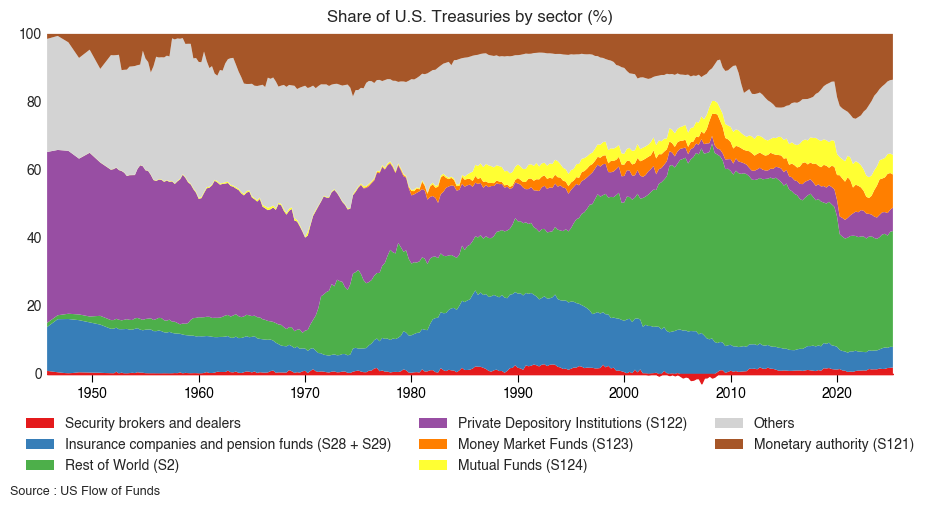

In [7]:
df_prop = df.div(all_sectors, axis=0)
df_prop = df_prop * 100
df_prop["Insurance companies and pension funds (S28 + S29)"] = df_prop["Insurance companies (S128)"] + df_prop["Pension Funds (S129)"]


# Sélection de quelques séries
selected = ["Security brokers and dealers",
            "Insurance companies and pension funds (S28 + S29)",
            "Rest of World (S2)",
            "Private Depository Institutions (S122)",
            "Money Market Funds (S123)",
            "Mutual Funds (S124)",
            "Monetary authority (S121)",
            ]

neg = df_prop["Security brokers and dealers"].clip(upper=0)
pos = df_prop["Security brokers and dealers"].clip(lower=0)
df_prop["Security brokers and dealers"] = pos

# Calcul de la part "Others"
df_prop = df_prop[selected].copy()
df_prop["Others"] = 100 - df_prop.sum(axis=1)

selected.remove("Monetary authority (S121)")
selected.append("Others")
selected.append("Monetary authority (S121)")
df_prop = df_prop[selected]


colors = list(plt.cm.get_cmap('Set1').colors[:7])        
colors.append('lightgray')
colors[-1], colors[-2] = colors [-2], colors [-1]



# Tracé
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(df_prop.index, df_prop.T, labels=df_prop.columns,colors=colors)
ax.set_xmargin(0)
ax.margins(y=0.01)
ax.set_facecolor('white')
ax.set_title("Share of U.S. Treasuries by sector (%)")
ax.fill_between(df_prop.index, neg, 0, color=colors[0])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# Forcer la spine du bas
ax.spines['bottom'].set_position(('data', 0))
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
#ax.spines['bottom'].set_linewidth(1.0)

# Forcer les ticks vers l'extérieur et visibles
ax.xaxis.set_ticks_position('bottom')
ax.tick_params(axis='x', which='both', direction='out', length=6, colors='black', bottom=True, top=False)

# S'assurer que les labels sont visibles
ax.xaxis.set_tick_params(labelcolor='black')

plt.xticks(rotation=0)
fig.text(0.04, -0.0, "Source : US Flow of Funds", ha="left", fontsize=9)

plt.tight_layout()
plt.show()

## IMF Historical Public Debt Database

In [7]:
df = fetch_series("IMF/HPDD/A.US.GGXWDG_GDP")
df = df[["original_period", "original_value"]]
df["original_period"] = pd.to_numeric(df["original_period"], errors='coerce')
df["original_value"] = pd.to_numeric(df["original_value"], errors='coerce')
df = df.dropna(subset=["original_period", "original_value"])
series = df.set_index("original_period")["original_value"]
series.index.name = None

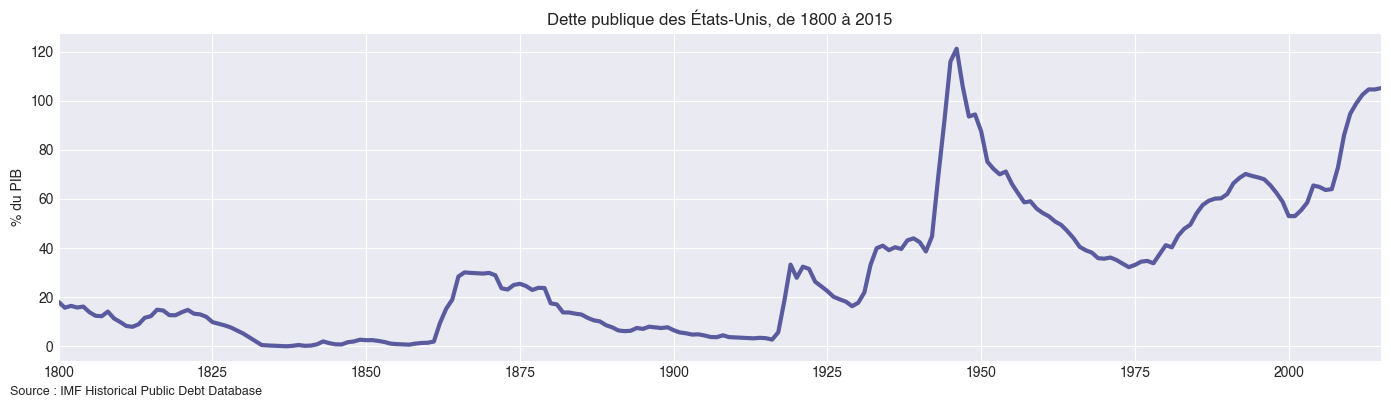

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series.index, series.values, linewidth=3)
ax.set_title("Dette publique des États-Unis, de 1800 à 2015")
ax.set_ylabel("% du PIB")
ax.set_xmargin(0)

fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database", ha="left", fontsize=9)
plt.tight_layout()
plt.show()

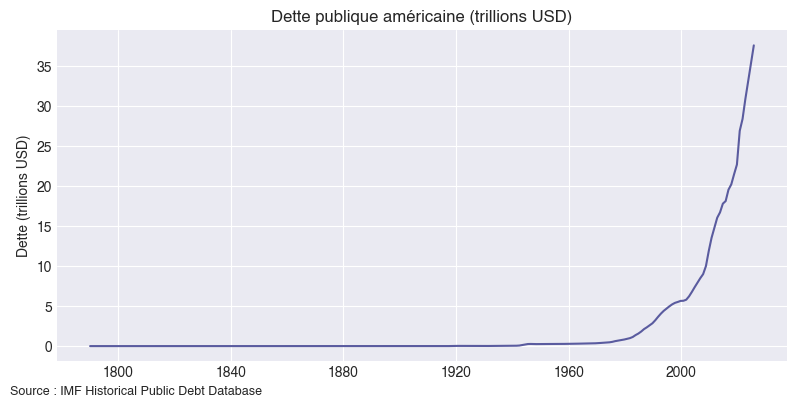

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# lecture du CSV
df = pd.read_csv("Data/HstDebt_17900101_20250930.csv")

# conversion de la colonne date
df["Record Date"] = pd.to_datetime(df["Record Date"])
df = df.sort_values("Record Date")  # tri par date
# création du graphique
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df["Record Date"], df["Debt Outstanding Amount"] / 1e12)
ax.set_title("Dette publique américaine (trillions USD)")
ax.set_ylabel("Dette (trillions USD)")
#ax.set_yscale('log')
fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database", ha="left", fontsize=9)
plt.tight_layout()
plt.show()


In [10]:
df = pd.read_csv("Data/HstDebt_17900101_20250930.csv")
df = df.sort_values("Record Date")
df["Record Date"] = pd.to_datetime(df["Record Date"], errors="coerce")
df["Record Date"] = df["Record Date"].dt.year.astype("Int64")
df["Debt Outstanding Amount"] = df["Debt Outstanding Amount"] / 1e12

series2 = df.set_index("Record Date")["Debt Outstanding Amount"]
series2.index.name = None

series2.head()

1790    0.000071
1791    0.000075
1792    0.000077
1793    0.000080
1794    0.000078
Name: Debt Outstanding Amount, dtype: float64

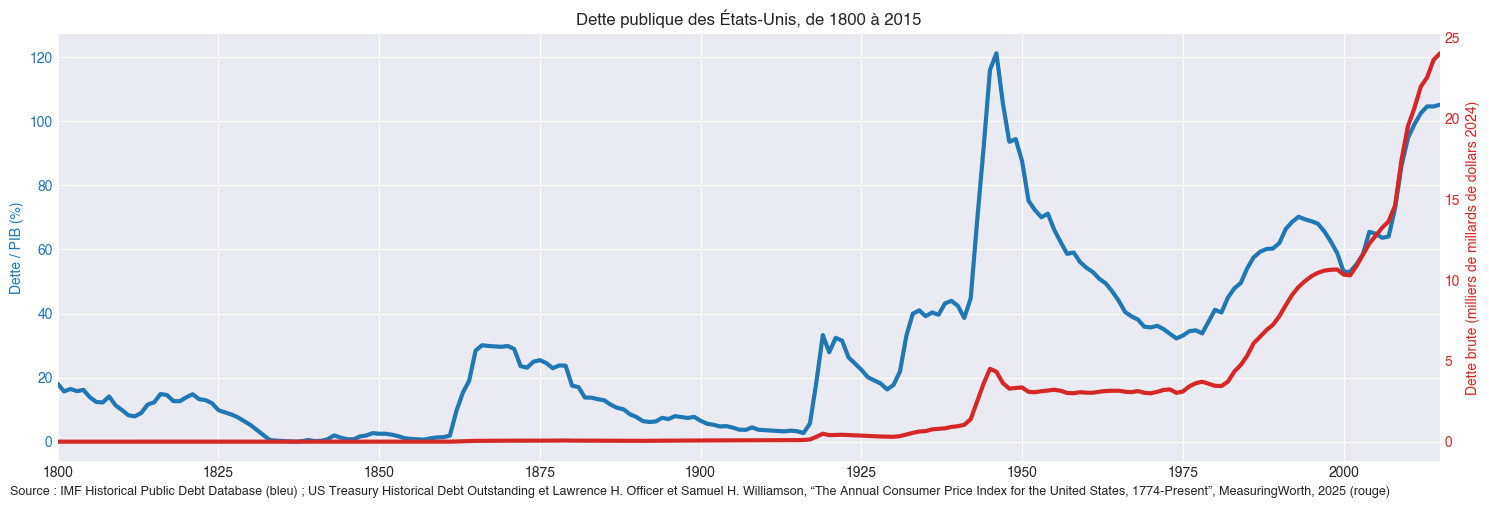

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import LinearLocator

s1 = series
s2 = real_price(series2)

s1 = s1.groupby(s1.index).mean()
s2 = s2.groupby(s2.index).mean()

# fusionner sur l’année commune
df = pd.DataFrame({
    "Debt_Pct_GDP": s1,
    "Debt_Absolute": s2
}).dropna()

# plot
fig, ax1 = plt.subplots(figsize=(15, 5))

# axe gauche : %
ax1.plot(df.index, df["Debt_Pct_GDP"], color="tab:blue", label="Dette / PIB (%)", linewidth=3)
ax1.set_ylabel("Dette / PIB (%)", color="tab:blue")
ax1.set_xmargin(0)
ax1.tick_params(axis="y", labelcolor="tab:blue")

# axe droit : USD log
ax2 = ax1.twinx()
ax2.plot(df.index, df["Debt_Absolute"], color="tab:red", label="Dette brute (USD)", linewidth=3)
#ax2.set_yscale("log")
ax2.set_ylabel("Dette brute (milliers de millards de dollars 2024)", color="tab:red")
ax2.set_xmargin(0)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax2.grid(False)
ax1.set_title("Dette publique des États-Unis, de 1800 à 2015")

fig.text(0.01, -0.0, "Source : IMF Historical Public Debt Database (bleu) ; US Treasury Historical Debt Outstanding et Lawrence H. Officer et Samuel H. Williamson, “The Annual Consumer Price Index for the United States, 1774-Present”, MeasuringWorth, 2025 (rouge)", ha="left", fontsize=9)
fig.tight_layout()
plt.show()


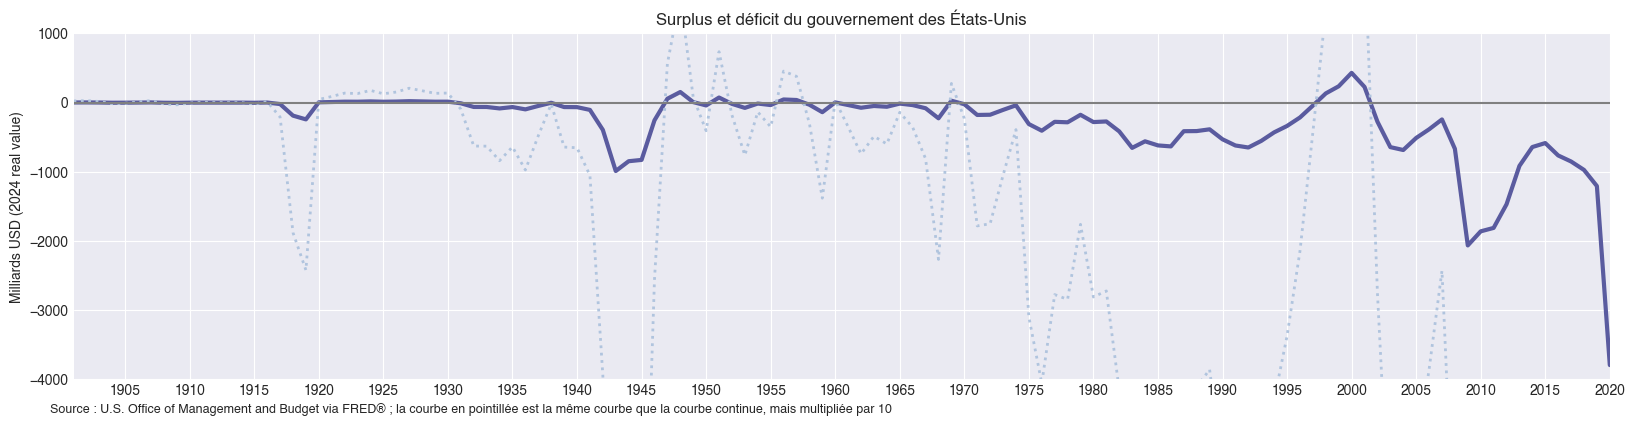

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# lecture du CSV
df = pd.read_csv("Data/FYFSD.csv")

# conversion de la colonne date
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date")  # tri par date
s = df.set_index(pd.to_datetime(df["observation_date"]).dt.year)["FYFSD"]
s.index.name = None
s = real_price(s)
s = s/1000

# création du graphique
fig, ax = plt.subplots(figsize=(16, 4))
plt.tight_layout()
s.loc[1900:2020].plot(ax=ax, linewidth=3)
s_zoom = s*10
s_zoom.loc[1900:2020].plot(ax=ax, linewidth=2, linestyle='dotted', color='lightsteelblue')
ax.set_title("Surplus et déficit du gouvernement des États-Unis")
ax.set_ylabel("Milliards USD (2024 real value)")
ax.set_xmargin(0)
ax.xaxis.set_major_locator(MaxNLocator(nbins=28)) 
ax.set_ylim(bottom=-4000, top=1000)

fig.text(0.01, -0.0, "Source : U.S. Office of Management and Budget via FRED® ; la courbe en pointillée est la même courbe que la courbe continue, mais multipliée par 10", ha="left", fontsize=9)
plt.axhline(0, color='gray')
plt.show()


/var/folders/my/3_9szq6j5z97dfcrfmtk4wq80000gn/T/ipykernel_28809/374072074.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([abs(int(tick)) for tick in ax.get_yticks()])


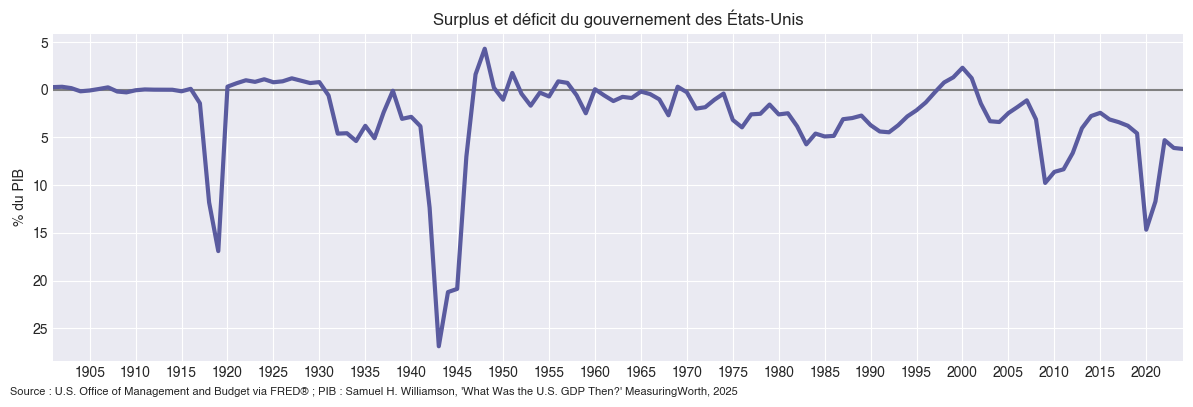

In [14]:
df = pd.read_csv("Data/FYFSD.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df.sort_values("observation_date")  # tri par date
s = df.set_index(pd.to_datetime(df["observation_date"]).dt.year)["FYFSD"]
s.index.name = None
s = 100*s/nominal_gdp

# création du graphique
fig, ax = plt.subplots(figsize=(12, 4))
plt.axhline(0, color='gray')

s.plot(ax=ax, linewidth=3)
ax.set_title("Surplus et déficit du gouvernement des États-Unis")
ax.set_ylabel("% du PIB")
ax.set_xmargin(0)
ax.xaxis.set_major_locator(MaxNLocator(nbins=28))
ax.set_yticklabels([abs(int(tick)) for tick in ax.get_yticks()])

"""
ax.annotate(
    "Budget restreint et \néquilibré",
    xy=(1909, -1),
    xytext=(1902, -7),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Première Guerre mondiale",
    xy=(1917, -10),
    xytext=(1904, -24),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=-0.3",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Austérité des\nannées 1920",
    xy=(1925, -0.5),
    xytext=(1922, -13),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Crise des\nannées 1930",
    xy=(1933, -6),
    xytext=(1924, -23),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.3",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Seconde Guerre mondiale",
    xy=(1946, -20),
    xytext=(1950, -26),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Budget important\n et (relativement) équilibré",
    xy=(1959, -5),
    xytext=(1952, -16),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.1",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Début du déficit permanent",
    xy=(1975, -4),
    xytext=(1970, -18),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=-0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Début de la consolidation fiscale,\naustérié sous Clinton",
    xy=(1992, -5),
    xytext=(1982, -13),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Crise de 2008",
    xy=(2009, -11),
    xytext=(2000, -22),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)

ax.annotate(
    "Covid",
    xy=(2020, -15),
    xytext=(2018, -20),
    arrowprops=dict(
        arrowstyle="->",  # style de flèche
        connectionstyle="arc3,rad=0.2",
        color="gray"
    ),
    fontsize=11,
    color="black"
)
"""

fig.text(0.01, -0.0, "Source : U.S. Office of Management and Budget via FRED® ; PIB : Samuel H. Williamson, 'What Was the U.S. GDP Then?' MeasuringWorth, 2025", ha="left", fontsize=8)

plt.tight_layout()
plt.show()
